# Lake Urmia Environmental Monitoring and Climate Analysis (2016–2025)

## Overview

This project investigates Lake Urmia surface water dynamics and its relationship with climate variability during 2016–2025 using Python-based environmental data analysis.

The dataset integrates:
- Satellite-derived surface water area observations
- Rainfall data
- Temperature records
- Summer SPEI drought index

The main objectives of this project are:
- Monitoring temporal changes in Lake Urmia surface water area
- Evaluating relationships between climate variables and water surface changes
- Developing a baseline regression model for surface water estimation and forecasting

Study period:

**2016–2025**

In [1]:
# Data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_excel(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Data\Lake_Urmia_Climate_Water_Dataset_2016_2025.xlsx"
)

df.head()

,Year,Water_Area_km2,Rainfall_mm,Temperature_C,SPEI_Summer
0,2016,3455.632574,388.291,10.540,-1.146
1,2017,3331.223189,328.688,10.822,-1.300
2,2018,3527.574485,562.404,11.707,-1.172
3,2019,3624.989843,459.284,10.787,-1.198
4,2020,3656.757288,433.543,10.362,-1.096


In [3]:
import pandas as pd

file_path = r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Data\Lake_Urmia_Climate_Water_Dataset_2016_2025.xlsx"

df = pd.read_excel(file_path)

df.head()

,Year,Water_Area_km2,Rainfall_mm,Temperature_C,SPEI_Summer
0,2016,3455.632574,388.291,10.540,-1.146
1,2017,3331.223189,328.688,10.822,-1.300
2,2018,3527.574485,562.404,11.707,-1.172
3,2019,3624.989843,459.284,10.787,-1.198
4,2020,3656.757288,433.543,10.362,-1.096


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            10 non-null     int64  
 1   Water_Area_km2  10 non-null     float64
 2   Rainfall_mm     10 non-null     float64
 3   Temperature_C   10 non-null     float64
 4   SPEI_Summer     10 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 532.0 bytes


## Statistical Summary

Descriptive statistics were calculated to summarize the main characteristics of the dataset, including central tendency, variability, and range of environmental variables.

In [5]:
df.describe()

,Year,Water_Area_km2,Rainfall_mm,Temperature_C,SPEI_Summer
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,2020.50000,3368.884683,387.163100,11.200600,-1.204600
std,3.02765,221.978745,80.965225,0.530048,0.080035
min,2016.00000,2966.603661,298.701000,10.362000,-1.305000
25%,2018.25000,3271.050748,329.288000,10.795750,-1.282250
50%,2020.50000,3393.427881,367.955000,11.348500,-1.196000
75%,2022.75000,3512.097489,426.035750,11.672500,-1.152500
max,2025.00000,3656.757288,562.404000,11.813000,-1.094000


In [6]:
df.describe().to_csv(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Results\statistical_summary.csv"
)

## 06. Lake Urmia Surface Water Dynamics (2016–2025)

This section analyzes the temporal variation of Lake Urmia surface water area during 2016–2025 based on annual water area observations.

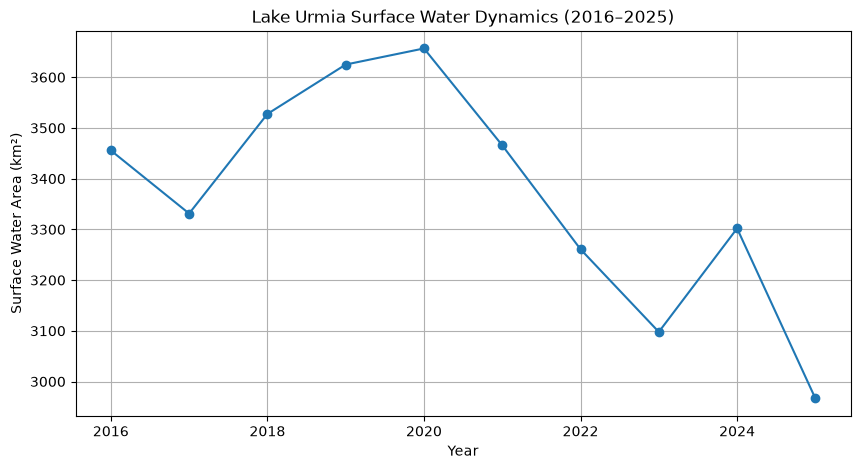

In [7]:
plt.figure(figsize=(10,5))

plt.plot(
    df["Year"],
    df["Water_Area_km2"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Surface Water Area (km²)")

plt.title("Lake Urmia Surface Water Dynamics (2016–2025)")

plt.grid(True)

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Lake_Urmia_Surface_Water_Dynamics_2016_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 07. Climate Variables Visualization (2016–2025)

This section presents the temporal variations of climate variables, including rainfall, temperature, and summer SPEI drought index during 2016–2025.


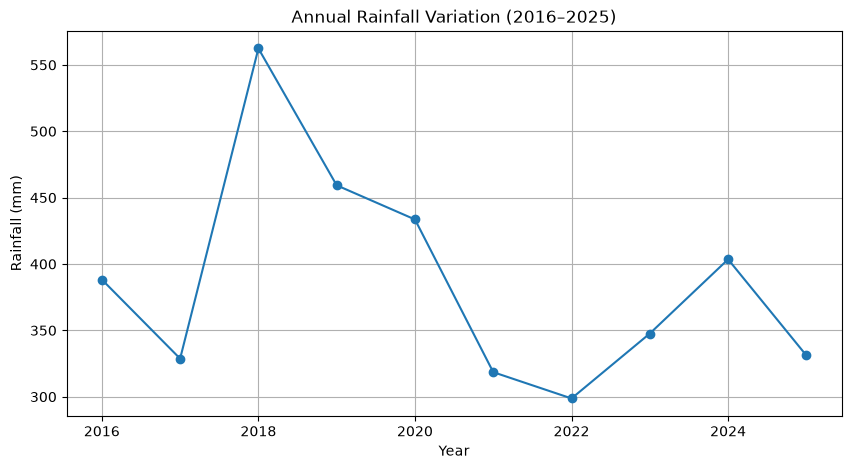

In [8]:
plt.figure(figsize=(10,5))

plt.plot(
    df["Year"],
    df["Rainfall_mm"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.title("Annual Rainfall Variation (2016–2025)")

plt.grid(True)

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Annual_Rainfall_Variation_2016_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

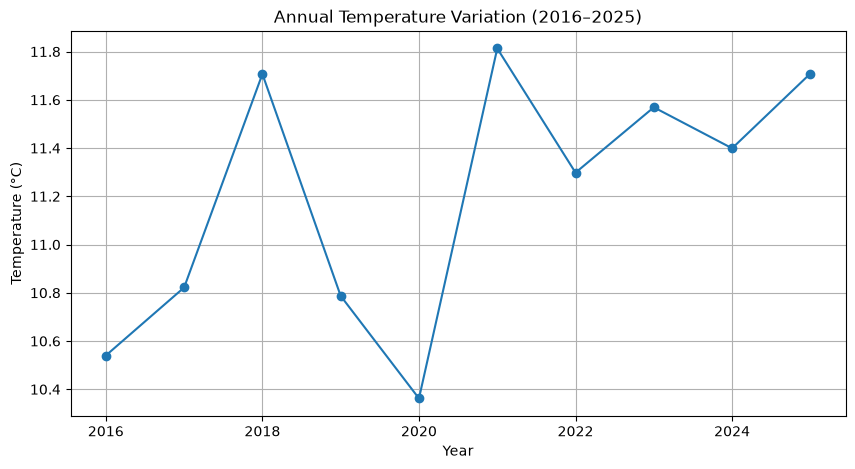

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    df["Year"],
    df["Temperature_C"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

plt.title("Annual Temperature Variation (2016–2025)")

plt.grid(True)

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Annual_Temperature_Variation_2016_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

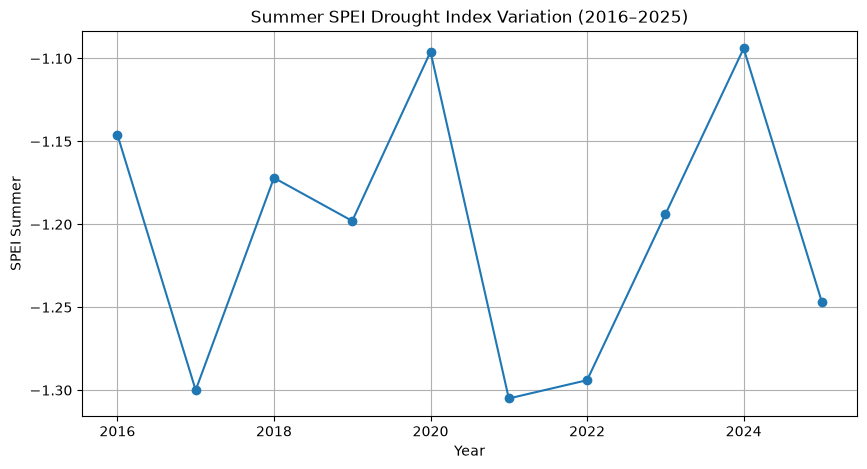

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    df["Year"],
    df["SPEI_Summer"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("SPEI Summer")

plt.title("Summer SPEI Drought Index Variation (2016–2025)")

plt.grid(True)

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Summer_SPEI_Variation_2016_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 08. Correlation Analysis

This section evaluates the relationships between Lake Urmia surface water area and climate variables using Pearson correlation analysis.

In [11]:
corr = df.corr()

corr

,Year,Water_Area_km2,Rainfall_mm,Temperature_C,SPEI_Summer
Year,1.000000,-0.664577,-0.376610,0.583458,-0.016966
Water_Area_km2,-0.664577,1.000000,0.599878,-0.546759,0.334721
Rainfall_mm,-0.376610,0.599878,1.000000,-0.127088,0.607669
Temperature_C,0.583458,-0.546759,-0.127088,1.000000,-0.381838
SPEI_Summer,-0.016966,0.334721,0.607669,-0.381838,1.000000


In [12]:
corr.to_csv(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Results\correlation_matrix.csv"
)

## 09. Correlation Heatmap Visualization

A correlation heatmap is generated to visualize the relationships between Lake Urmia surface water area and climate variables.

In [13]:
import seaborn as sns

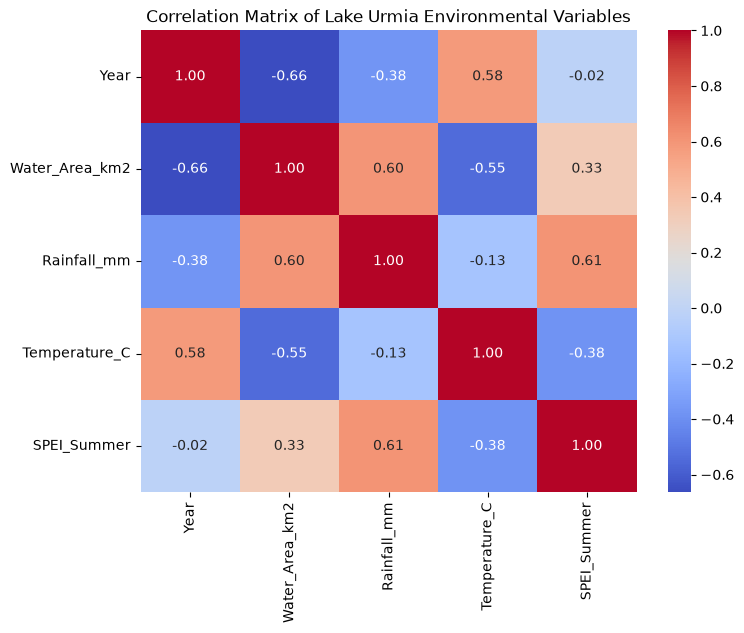

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Lake Urmia Environmental Variables")

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Trend Analysis of Surface Water Change

A linear regression model is applied to estimate the temporal trend of Lake Urmia surface water area during 2016–2025.

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [16]:
X = df[["Year"]]
y = df["Water_Area_km2"]

In [17]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-48.72]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.018e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [18]:
from scipy.stats import linregress

trend = linregress(
    df["Year"],
    df["Water_Area_km2"]
)

slope = trend.slope
intercept = trend.intercept

print(f"Surface water annual trend: {slope:.2f} km²/year")

Surface water annual trend: -48.72 km²/year


In [19]:
print(f"Surface water annual trend: {slope:.2f} km²/year")

Surface water annual trend: -48.72 km²/year


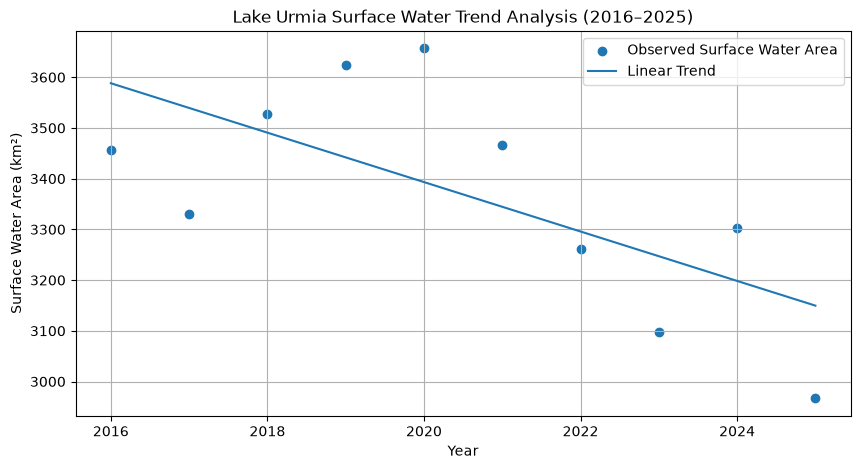

In [20]:
plt.figure(figsize=(10,5))

plt.scatter(
    df["Year"],
    df["Water_Area_km2"],
    label="Observed Surface Water Area"
)

plt.plot(
    df["Year"],
    model.predict(X),
    label="Linear Trend"
)

plt.xlabel("Year")
plt.ylabel("Surface Water Area (km²)")

plt.title("Lake Urmia Surface Water Trend Analysis (2016–2025)")

plt.grid(True)

plt.legend()

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Surface_Water_Trend_Analysis_2016_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Climate–Water Relationship Analysis

This section investigates the relationship between Lake Urmia surface water area and climate variables using scatter plots.

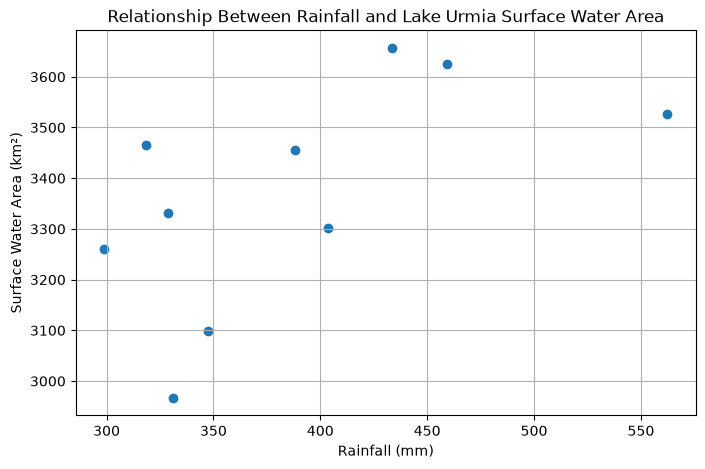

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Rainfall_mm"],
    df["Water_Area_km2"]
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Surface Water Area (km²)")

plt.title("Relationship Between Rainfall and Lake Urmia Surface Water Area")

plt.grid(True)

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Water_Area_vs_Rainfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

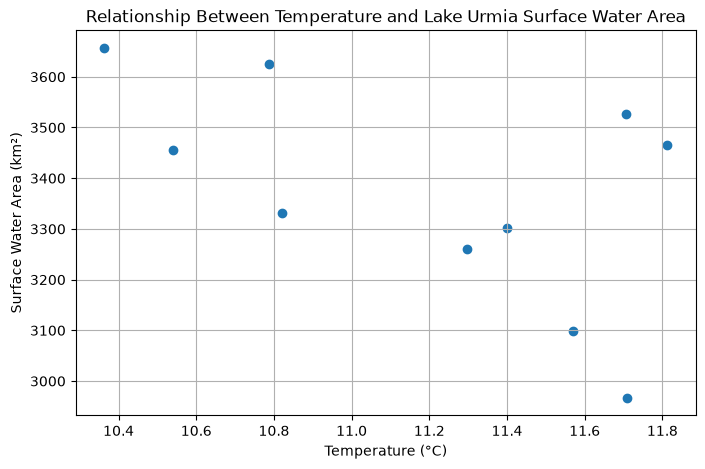

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Temperature_C"],
    df["Water_Area_km2"]
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Surface Water Area (km²)")

plt.title("Relationship Between Temperature and Lake Urmia Surface Water Area")

plt.grid(True)

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Water_Area_vs_Temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

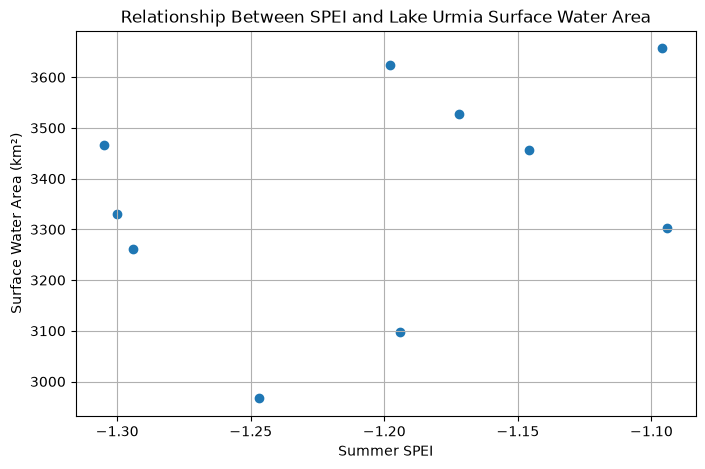

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["SPEI_Summer"],
    df["Water_Area_km2"]
)

plt.xlabel("Summer SPEI")
plt.ylabel("Surface Water Area (km²)")

plt.title("Relationship Between SPEI and Lake Urmia Surface Water Area")

plt.grid(True)

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Water_Area_vs_SPEI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Multiple Linear Regression Model

A multiple linear regression model is developed to estimate Lake Urmia surface water area based on climate variables, including rainfall, temperature, and summer SPEI.

In [24]:
X = df[[
    "Rainfall_mm",
    "Temperature_C",
    "SPEI_Summer"
]]

y = df["Water_Area_km2"]

In [25]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 1.99,-242.7 ,-907.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Rainfall_mm','Temperature_C','SPEI_Summer']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4225
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [26]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred = lr_model.predict(X)

r2 = r2_score(y, y_pred)

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.6422860170889064
RMSE: 125.95070538014642
MAE: 91.81609438704318


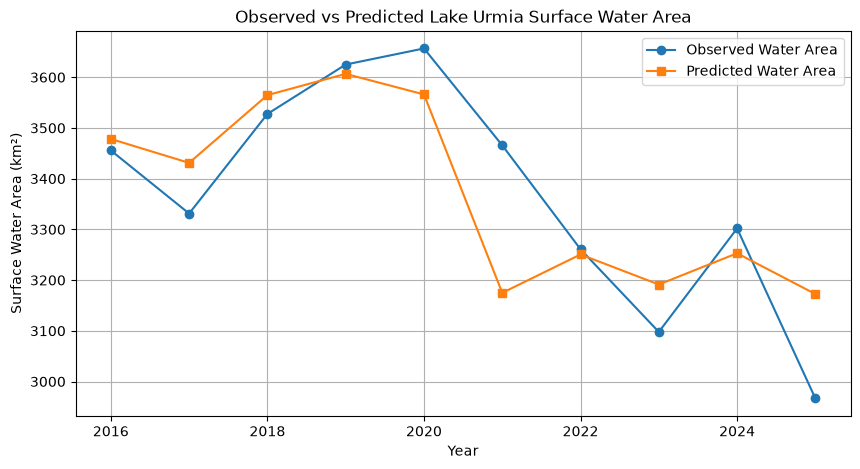

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    df["Year"],
    y,
    marker="o",
    label="Observed Water Area"
)

plt.plot(
    df["Year"],
    y_pred,
    marker="s",
    label="Predicted Water Area"
)

plt.xlabel("Year")
plt.ylabel("Surface Water Area (km²)")

plt.title("Observed vs Predicted Lake Urmia Surface Water Area")

plt.grid(True)

plt.legend()

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Observed_vs_Predicted_Water_Area.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
results = pd.DataFrame({
    "Year": df["Year"],
    "Observed_Water_Area_km2": y,
    "Predicted_Water_Area_km2": y_pred
})

results

,Year,Observed_Water_Area_km2,Predicted_Water_Area_km2
0,2016,3455.632574,3478.286411
1,2017,3331.223189,3431.096065
2,2018,3527.574485,3564.736566
3,2019,3624.989843,3606.635852
4,2020,3656.757288,3566.070851
5,2021,3465.666500,3174.862242
6,2022,3260.781480,3250.519627
7,2023,3097.759261,3191.252170
8,2024,3301.858553,3252.884619
9,2025,2966.603661,3172.502430


In [29]:
results.to_csv(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Results\Observed_vs_Predicted_Water_Area.csv",
    index=False
)

In [30]:
metrics = pd.DataFrame({
    "Metric": ["R2", "RMSE_km2", "MAE_km2"],
    "Value": [r2, rmse, mae]
})

metrics

,Metric,Value
0,R2,0.642286
1,RMSE_km2,125.950705
2,MAE_km2,91.816094


In [31]:
metrics.to_csv(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Results\Model_Performance_Metrics.csv",
    index=False
)

## 14. Future Surface Water Forecasting (2026–2030)

A baseline forecast is generated using the linear regression model to estimate future Lake Urmia surface water area for 2026–2030.

In [32]:
future_years = pd.DataFrame({
    "Year": [2026, 2027, 2028, 2029, 2030]
})

future_years

,Year
0,2026
1,2027
2,2028
3,2029
4,2030


In [33]:
future_water_prediction = model.predict(
    future_years[["Year"]]
)

future_water_prediction

array([3100.8978612 , 3052.17298444, 3003.44810767, 2954.72323091,
       2905.99835415])

In [34]:
forecast_results = pd.DataFrame({
    "Year": future_years["Year"],
    "Forecasted_Water_Area_km2": future_water_prediction
})

forecast_results

,Year,Forecasted_Water_Area_km2
0,2026,3100.897861
1,2027,3052.172984
2,2028,3003.448108
3,2029,2954.723231
4,2030,2905.998354


In [35]:
forecast_results.to_csv(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Results\Future_Water_Area_Forecast_2026_2030.csv",
    index=False
)

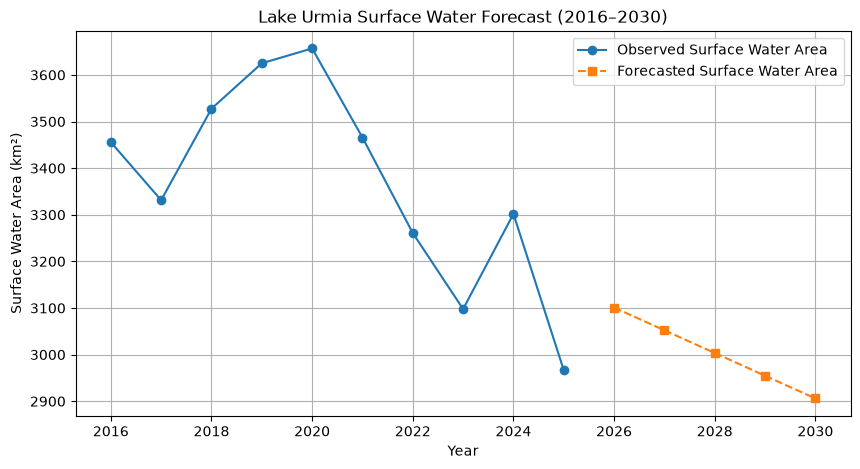

In [36]:
plt.figure(figsize=(10,5))

# Historical data
plt.plot(
    df["Year"],
    df["Water_Area_km2"],
    marker="o",
    label="Observed Surface Water Area"
)

# Forecast data
plt.plot(
    forecast_results["Year"],
    forecast_results["Forecasted_Water_Area_km2"],
    marker="s",
    linestyle="--",
    label="Forecasted Surface Water Area"
)

plt.xlabel("Year")
plt.ylabel("Surface Water Area (km²)")

plt.title("Lake Urmia Surface Water Forecast (2016–2030)")

plt.grid(True)

plt.legend()

plt.savefig(
    r"C:\Users\kk\Desktop\Lake_Urmia_Project1\Figures\Lake_Urmia_Surface_Water_Forecast_2016_2030.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15. Final Project Summary and Conclusions

## Project Overview

This project investigated Lake Urmia surface water dynamics and climate variability during 2016–2025 using Python-based environmental data analysis and remote sensing-derived water area observations.

The workflow included:
- Surface water area trend analysis
- Climate variable visualization
- Correlation analysis
- Linear regression modeling
- Baseline future surface water forecasting (2026–2030)

## Main Findings

- Lake Urmia surface water area exhibited an overall declining trend during the study period.
- Linear regression estimated an annual surface water change rate of approximately -48.72 km²/year.
- Rainfall showed a positive relationship with surface water area, while temperature showed a negative relationship.
- The baseline regression model explained approximately 44% of the observed variability in surface water area (R² = 0.44).

## Model Limitations

Due to the limited number of observations (10 annual records), the forecasting results should be interpreted as a baseline estimation rather than a final predictive model.

Future improvements may include:
- Extending the analysis using longer-term satellite observations
- Incorporating monthly or seasonal climate variables
- Adding hydrological variables such as evapotranspiration and water inflow
- Applying advanced machine learning and deep learning approaches

## Conclusion

This notebook demonstrates an integrated workflow for monitoring lake surface water changes and evaluating climate impacts using remote sensing-derived observations, environmental data analysis, and Python-based modeling techniques.